## House price dataset Model training 
Using EDA.ipynb get processed data and train the data using basic regressing model 
- Linear Regression 
- Ridge 
- Lasso 
- ElasticNet 
metics MSE(Mean Square Error ),R2 score 



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Nihal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


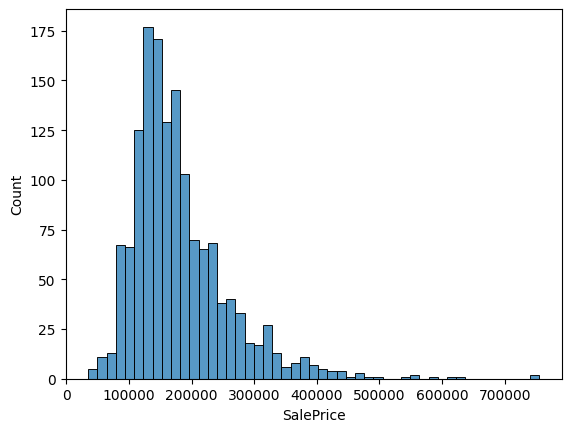

C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed indivi

Target looks like regression


C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:111: UserWarning: Showing only top 10 continuous features.
  warn("Showing only top 10 continuous features.")


Showing only top 10 of 44 categorical features


C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].median()
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].median()
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0

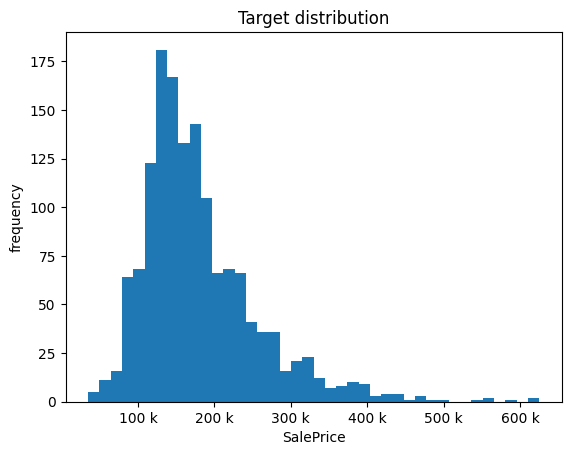

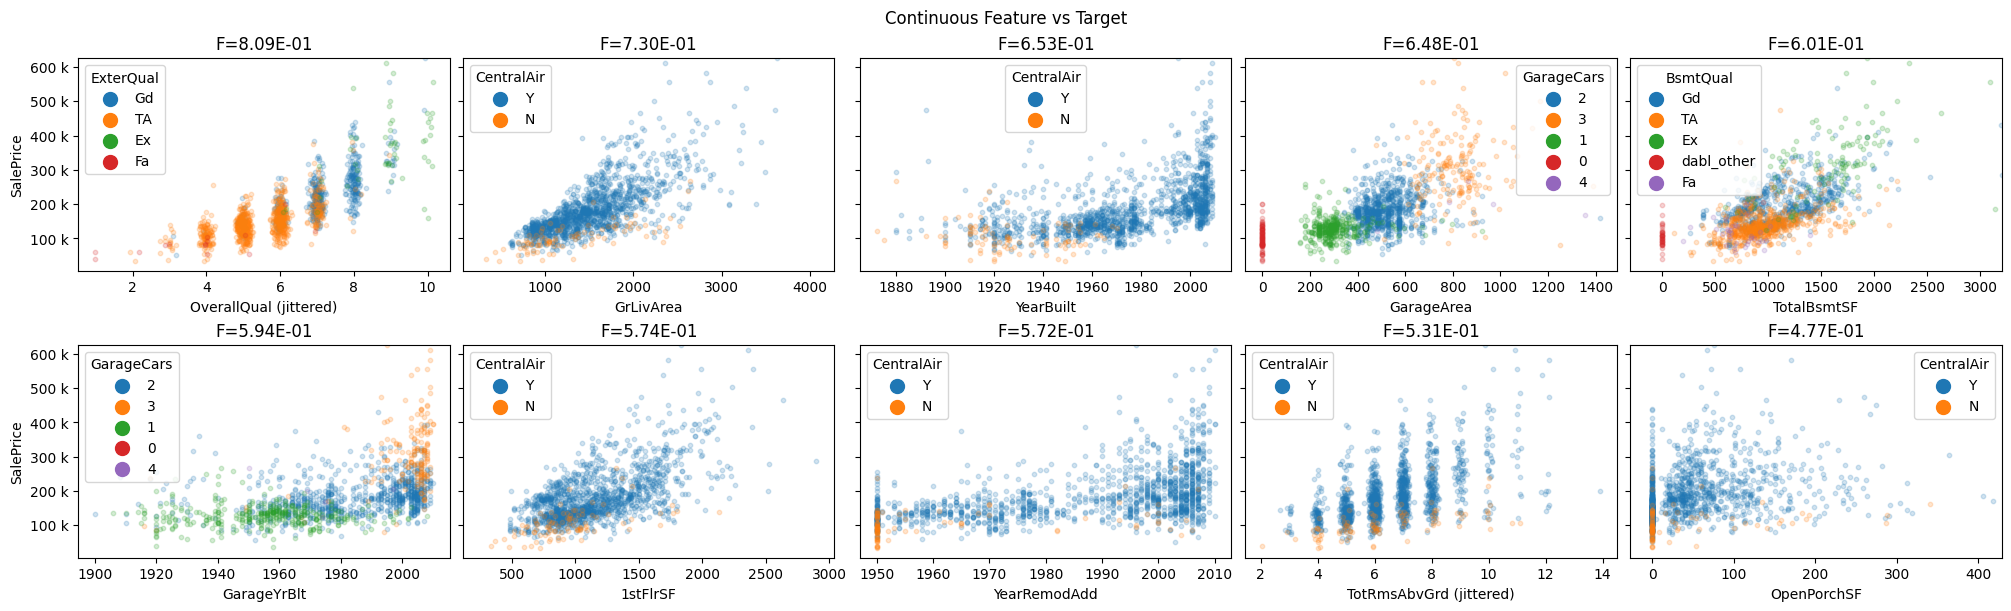

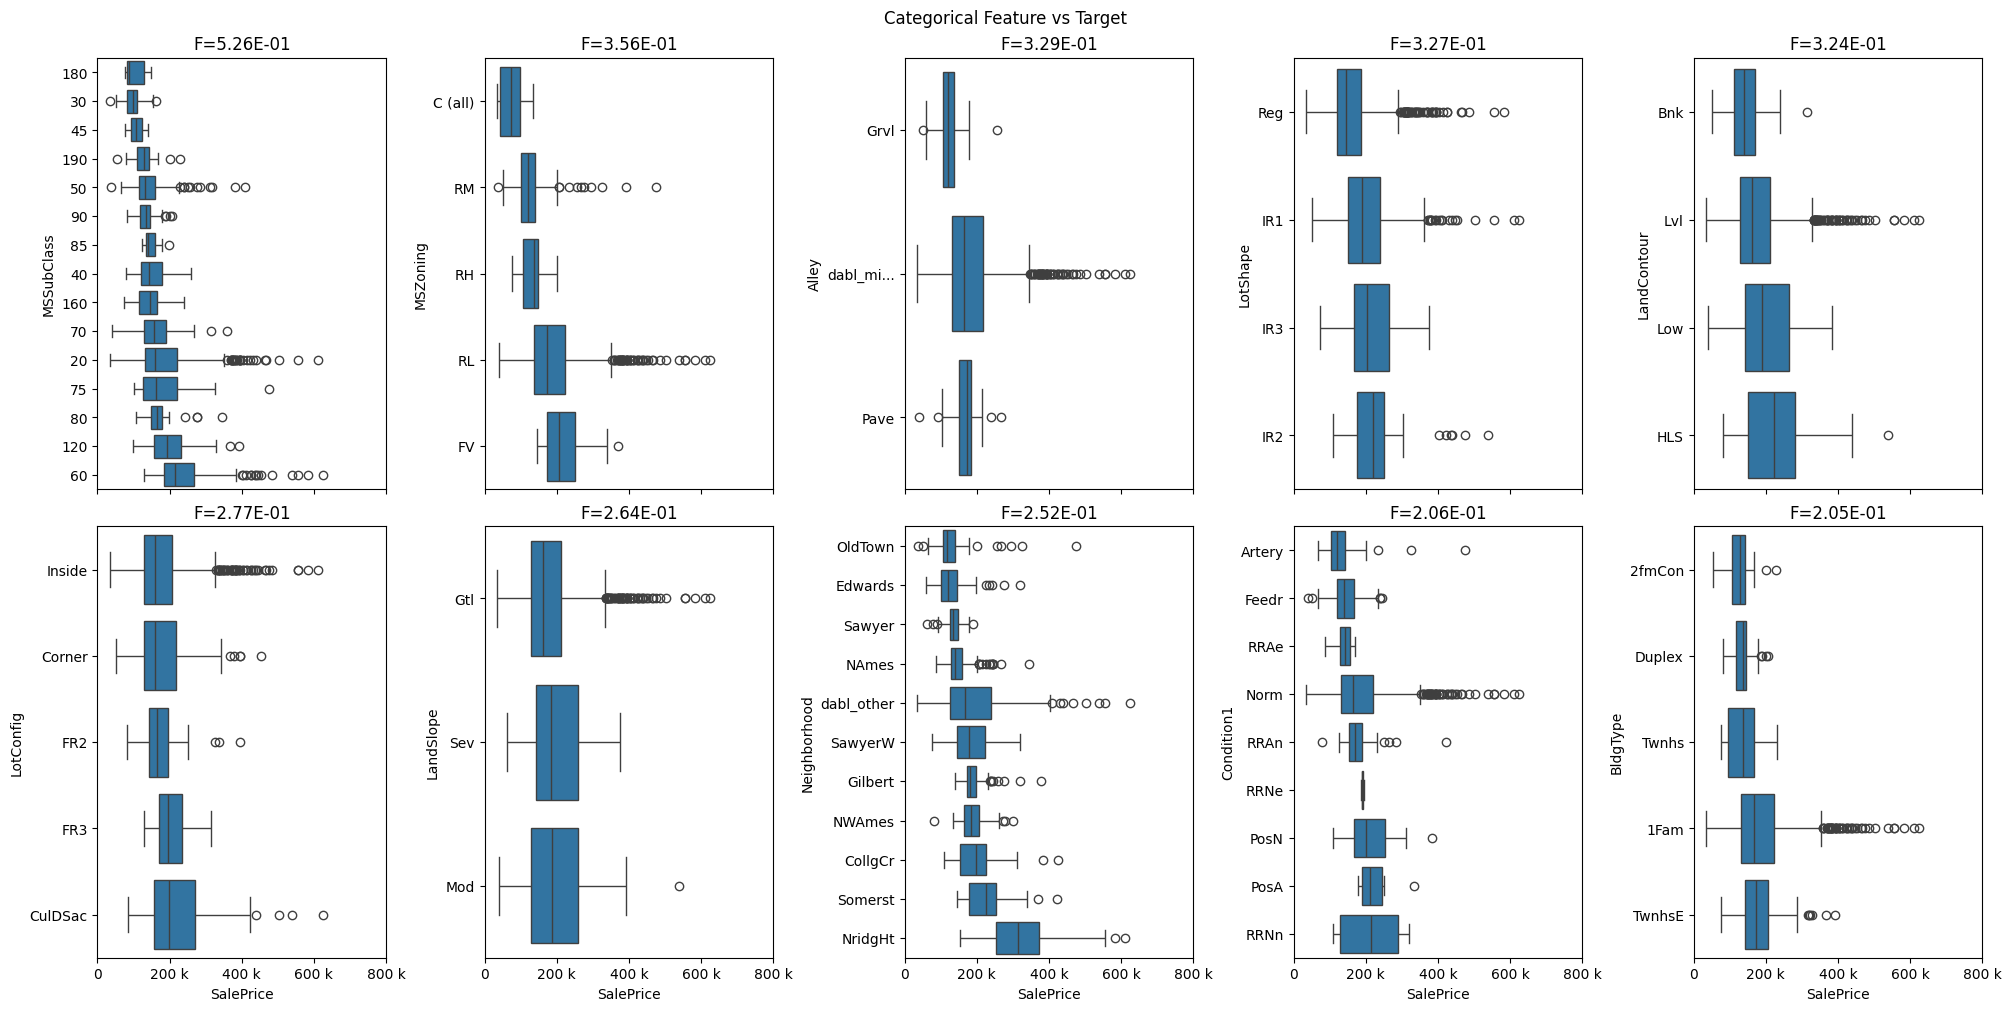

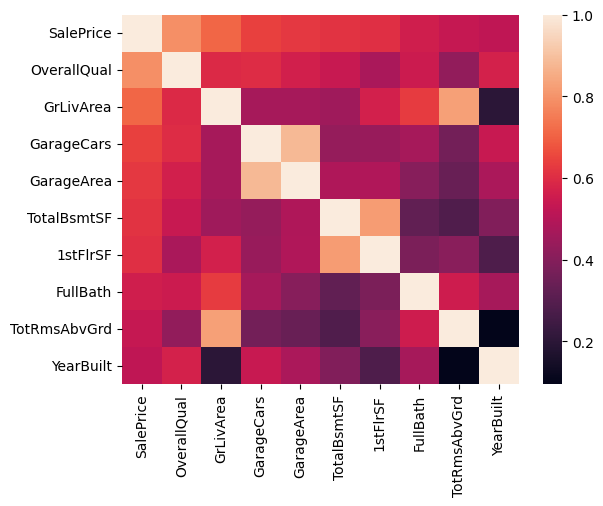

Target looks like regression


C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\utils.py:712: UserWarning: Dropped 2 outliers in column SalePrice.
  warn("Dropped {} outliers in column {}.".format(
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:652: UserWarning: Discarding 2 outliers in target column.
  warn(f"Discarding {n_outliers} outliers in target column.",
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].med

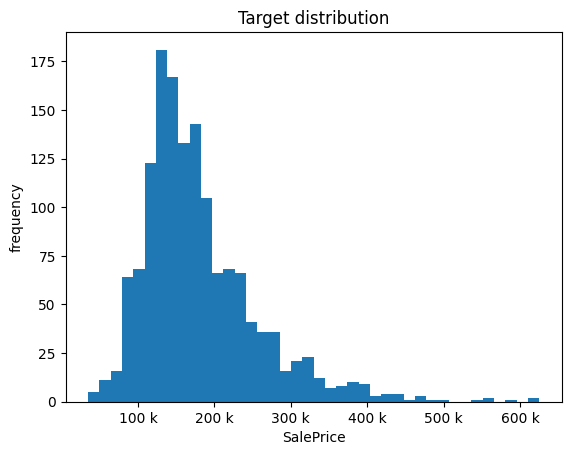

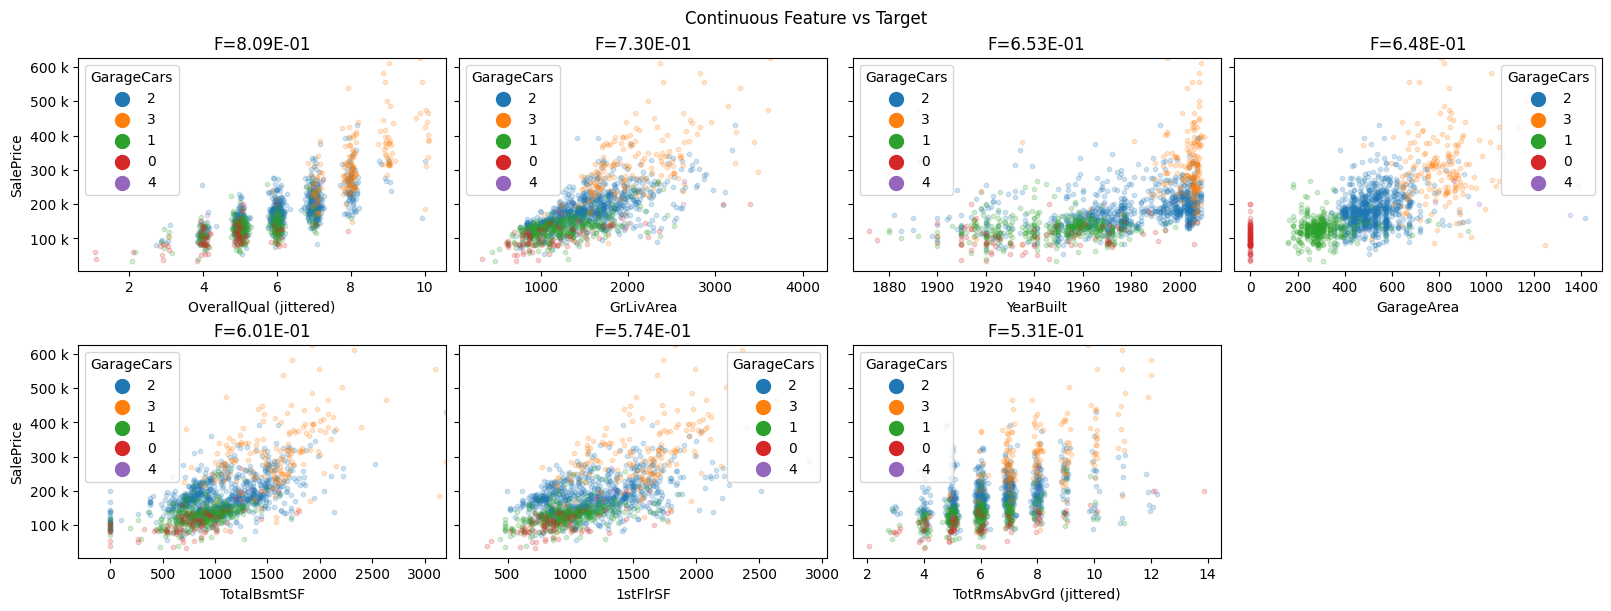

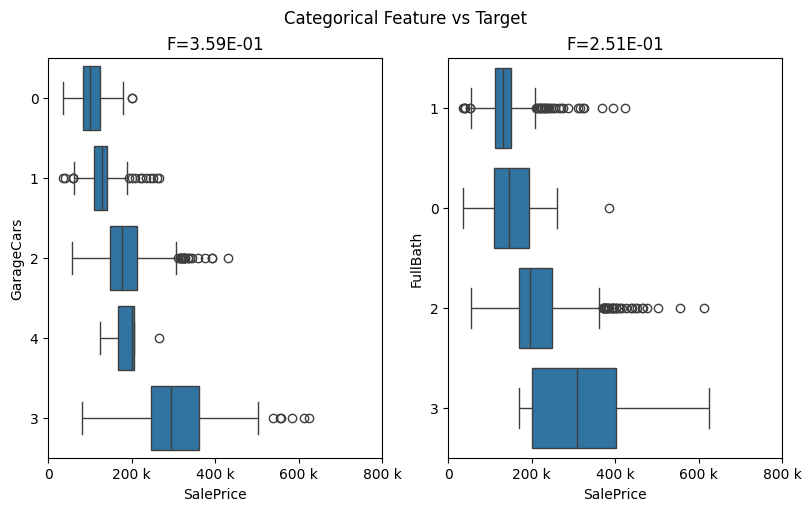

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalePrice     1460 non-null   int64
 1   OverallQual   1460 non-null   int64
 2   GrLivArea     1460 non-null   int64
 3   GarageCars    1460 non-null   int64
 4   GarageArea    1460 non-null   int64
 5   TotalBsmtSF   1460 non-null   int64
 6   1stFlrSF      1460 non-null   int64
 7   FullBath      1460 non-null   int64
 8   TotRmsAbvGrd  1460 non-null   int64
 9   YearBuilt     1460 non-null   int64
dtypes: int64(10)
memory usage: 114.2 KB


In [5]:
# using EDA data of house price prediction to implement regression models 
# libraries used to run regression models and scaling data 
import sys
!{sys.executable} -m pip install nbformat
%run ./EDA.ipynb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression ,Ridge ,Lasso, ElasticNet
from sklearn.metrics import mean_squared_error ,r2_score
from sklearn.preprocessing import StandardScaler

## This is the regerssion model with all types of upgrade like Losso Ridge and ElasticNet 
- EDA involves only removing NULL values ,Duplicates,top k elements which are correlated 
- Need more improvements like removing Outliers ,log tranforme features ,crossvidation,catogorical encoding and Feature engineering 

In [6]:
# Train Test and split data to use in models 
#implement Ridge L2 and Lasso L1 and ElasticNet for both test and train data 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=54)
models={
    "Linear" :LinearRegression(),
    "Ridge" :Ridge(alpha=10),
    "Lasso":Lasso(alpha=0.01),
    "ElasitcNet":ElasticNet(alpha=0.01,l1_ratio=0.5)
}
scaler=StandardScaler()
x_train_scale=scaler.fit_transform(x_train)
x_test_scale=scaler.transform(x_test)

performance_data=[]
for name,model in models.items():
    model.fit(x_train_scale,y_train)

    train_pred=model.predict(x_train_scale)
    test_pred=model.predict(x_test_scale)

    performance_data.append({
        "model": name,
        "train MSE": mean_squared_error(y_train,train_pred),
        "test MSE":mean_squared_error(y_test,test_pred),
        "r2 train":r2_score(y_train,train_pred),
        "r2 test":r2_score(y_test,test_pred)
    })
result=pd.DataFrame(performance_data)
print(result.to_string(index=False))


     model    train MSE     test MSE  r2 train  r2 test
    Linear 1.321785e+09 1.831095e+09  0.787989 0.716834
     Ridge 1.322249e+09 1.816879e+09  0.787914 0.719033
     Lasso 1.321785e+09 1.831094e+09  0.787989 0.716834
ElasitcNet 1.321912e+09 1.823472e+09  0.787968 0.718013
